<a href="https://colab.research.google.com/github/JohnYechanJo/3D-Brain-Tumor-Segmentation/blob/main/3D_Brain_Tumor_Segmentation_EDA_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install monai
!pip install natsort

  Obtaining dependency information for monai from https://files.pythonhosted.org/packages/08/94/e8a7ba00dd0c7ce959648b562043bd22125d65f5e519e566c822f71bc437/monai-1.3.0-202310121228-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.9 MB/s eta 0:00:00
  Obtaining dependency information for natsort from https://files.pythonhosted.org/packages/ef/82/7a9d0550484a62c6da82858ee9419f3dd1ccc9aa1c26a1e43da3ecd20b0d/natsort-8.4.0-py3-none-any.whl.metadata


# Introduction
* Brain tumor Semantic segmentation
* Dataset: Brats 2020 = Well Known Tumor Dataset.
* Brats: Tumor dataset
* Multi-Modal: Brain의 여러 domain을 한번에 활용하여 접근
* 총 4개의 modal 있음
  * T2 and FLAIR의 경우 tissue water relaxational properties(조직 수분)을 보기에 용이함. (영역이 넓음)
  * T1의 경우 병변의 대한 위치를 나타내며 각기 다른 특징들을 뽑을수 있다.
  * T1Gd 조영제를 투과하여 T1의 영상의 contrast를 올린 영상 , 혈관이 잘 보이는 특징을 가지고 있음.

## Why need image processing?
* Brain Tumor중에서 Gliomas라는 종류로서 33%의 비중을 차지.
* 이러한 환자의 진단은 여전히 어렵고 발병시 2년 이하의 생존률을 가지는 위험한 병.
* 하지만 이러한 병변을 판단하는건 가장 큰 지름 + 정성적인 평가로만 가능 -> 그렇다면 Image processing의역할이 필요함.
* 결국 이러한 방법들은 자동적으로 tumor의 영역을 측정하는데 필요함.
* MICCAI 2020년에 solution을 기반한 논문도 출간 되었음.

## How get annotation?
* 정확한 annotation을 얻기 위해서는 다양한 modal에서 영상의 annotation이 필요함.
* 총 3개의 class가 있음.
  * enhancing tumor (ET) : Tumor가 종양으로 커지고 있는 영역 (T1Gd에서 잘보임)
  * non enhancing tumor (NET) & necrotic tumor (NCR) : 종양부분 커지지 않는 영역 (T1Gd & T1에서 잘보임)
  * peritumoral edema (ED): 종양 주위에 발생하는 부종 (FLAIR)에서 잘보임
  * ET/NET/NCR영역을 합하여 tumor core를 만들어냄.
  * 마지막으로 ED를 붙이면 전체 tumor가 완성이 되어짐.
  

* 중앙 : t1에 mask입힌 영상, 빨간색 : ET, 초록색 : NET&NCR, 노락색 : ED
* 왼쪽 위 : T2, 오른쪽 위 : T1, 왼쪽 아래 : T1Gd, 오른쪽 아래 : FLAIR

# 1. EDA

In [ ]:
from pathlib import Path
from natsort import natsorted
from tqdm.notebook import tqdm
from IPython.display import display
from scipy import ndimage

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
class cfg:
    base_path = Path('/kaggle/input/brats20-dataset-training-validation/')
    train_path = base_path/'BraTS2020_TrainingData'/'MICCAI_BraTS2020_TrainingData'
    valid_path = base_path/'BraTS2020_ValidationData'/'MICCAI_BraTS2020_ValidationData'
    train_meta_csv   = train_path/'name_mapping.csv'
    train_survival_csv   = train_path/'survival_info.csv'

    valid_meta_csv   = valid_path/'name_mapping.csv'
    valid_survival_csv   = valid_path/'survival_info.csv'

### 1.1 Check & Counting data
* data의 위치 확인 및 갯수 확인은 필요하다.

In [ ]:
check_file = lambda x : x if x.is_file() else None
## load all dataset folder
data_dict = {'Brats20ID':[], 'flair':[], 't1':[], 't1ce':[], 't2':[], 'mask':[]}
folder_pathes = natsorted(list(cfg.train_path.glob('*')))

data_dicts = []
for sample_path in tqdm(folder_pathes):
    ## get images and labels
    flair_path = sample_path/str(sample_path.name+'_flair.nii')
    t1_path     = sample_path/str(sample_path.name+'_t1.nii')
    t1ce_path   = sample_path/str(sample_path.name+'_t1ce.nii')
    t2_path     = sample_path/str(sample_path.name+'_t2.nii')
    mask_path   = sample_path/str(sample_path.name+'_seg.nii')

    data_dict['Brats20ID'].append(sample_path.name)
    data_dict['flair'].append(check_file(flair_path))
    data_dict['t1'].append(check_file(t1_path))
    data_dict['t1ce'].append(check_file(t1ce_path))
    data_dict['t2'].append(check_file(t2_path))
    data_dict['mask'].append(check_file(mask_path))

df = pd.DataFrame(data_dict)

  0%|          | 0/371 [00:00<?, ?it/s]

In [ ]:
# check NAN value
df.isna().sum()
display(df.count())
train = df.dropna().reset_index(drop=True)
display(train.count())

Brats20ID    371
flair        369
t1           369
t1ce         369
t2           369
mask         368
dtype: int64

Brats20ID    368
flair        368
t1           368
t1ce         368
t2           368
mask         368
dtype: int64

<Axes: >

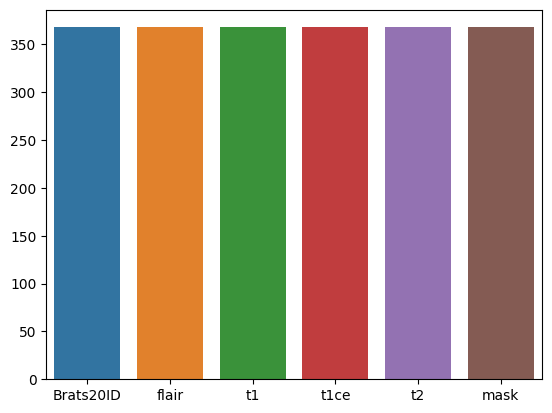

In [ ]:
sns.barplot(train.count().to_frame().T)

## 1.2 get all meta data
* 모든 데이터의 meta data를 읽어봅시다.

In [ ]:
train.head()

,Brats20ID,flair,t1,t1ce,t2,mask
0,BraTS20_Training_001,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...
1,BraTS20_Training_002,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...
2,BraTS20_Training_003,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...
3,BraTS20_Training_004,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...
4,BraTS20_Training_005,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...,/kaggle/input/brats20-dataset-training-validat...


* 현제 Brats에서 제공해주고 있는 Survival csv도 함께 읽어와서 지금 데이터와 병합을 해봅니다.

In [ ]:
train_survival_df = pd.read_csv(cfg.train_survival_csv)
merge_df = train.merge(train_survival_df, how='inner', on='Brats20ID')

* nifity파일을 읽어오기 위해서는 다양한 tool이 있습니다.
* 대표적으로 Simple ITK & nibabel이 있는데요
* 이 두개의 라이브러리를 비교해보고 또한 meta data추출까지 진행을 해보록 하겠습니다.

In [ ]:
import SimpleITK as sitk
import nibabel as nib

In [ ]:
all_data_path = merge_df[['flair','t1','t1ce','t2']].values # dataframe load하여 동일한 이미지 추출

img = sitk.ReadImage(all_data_path[0][0]) # flair이미지 추가 후 속도 측정
%time a = sitk.GetArrayFromImage(img)
img = nib.load(all_data_path[0][0])
%time a = img.get_fdata()

CPU times: user 2.39 ms, sys: 2.21 ms, total: 4.6 ms
Wall time: 6.28 ms
CPU times: user 4.84 ms, sys: 7.99 ms, total: 12.8 ms
Wall time: 13.5 ms


* Sitk가 빠른것을 확인이 되었으나 nifity와 itk두개의 라이브러리에서 필수 meta data를 추출해봅시다.

In [ ]:
# https://bo-10000.tistory.com/27

In [ ]:
## nibabel version
sample_img = nib.load(all_data_path[0][0])

name = all_data_path[0][0].name
sample_header = sample_img.header
img = sample_img.get_fdata()
print(f'file name : {name}')
print(f'image shape : {sample_header.get_data_shape()}')
print(f'Pixel spacing : {sample_header.get_zooms()}')
print(f'Data type : {sample_header.get_data_dtype()}')
print(f'Min, Max value : {np.min(img), np.max(img)}')
print('-------------------------------------------------')
# # ## nibabel version
sample_img = sitk.ReadImage(all_data_path[0][0])
img = sitk.GetArrayFromImage(sample_img)
print(f'image shape : {sample_img.GetSize()}')
print(f'Pixel spacing : {sample_img.GetSpacing()}')
print(f'Data type : {sample_img.GetPixelIDTypeAsString()}')
print(f'Min, Max value :{np.min(img), np.max(img)}')

file name : BraTS20_Training_001_flair.nii
image shape : (240, 240, 155)
Pixel spacing : (1.0, 1.0, 1.0)
Data type : int16
Min, Max value : (0.0, 625.0)
-------------------------------------------------
image shape : (240, 240, 155)
Pixel spacing : (1.0, 1.0, 1.0)
Data type : 16-bit signed integer
Min, Max value :(0, 625)


In [ ]:
def extract_meta_data(sample_path, use_itk=True):

    if use_itk:
        sample_img = sitk.ReadImage(sample_path)
        img = sitk.GetArrayFromImage(sample_img)
        return np.min(img), np.max(img), sample_img.GetSize(), sample_img.GetSpacing()
    else:
        sample_img = nib.load(sample_path)
        sample_header = sample_img.header
        img = sample_img.get_fdata()
        return np.min(img), np.max(img), sample_header.get_data_shape(), sample_header.get_zooms()

print(extract_meta_data(all_data_path[0][0]))

(0, 625, (240, 240, 155), (1.0, 1.0, 1.0))


In [ ]:
meta_dict = {'flair_mima':[],'flair_shape':[],'flair_space':[],
             't1_mima':[],'t1_shape':[],'t1_space':[],
             't1ce_mima':[],'t1ce_shape':[],'t1ce_space':[],
             't2_mima':[],'t2_shape':[],'t2_space':[]}
for multi_modal_path in tqdm(all_data_path):
    flair_path, t1_path, t1ce_path, t2_path = multi_modal_path
    result = [extract_meta_data(i) for i in multi_modal_path]
    flair_meta, t1_meta, t1ce_meta, t2_meta = result

    meta_dict['flair_mima'].append([flair_meta[0],flair_meta[1]])
    meta_dict['flair_shape'].append(flair_meta[2])
    meta_dict['flair_space'].append(flair_meta[3])

    meta_dict['t1_mima'].append([t1_meta[0],t1_meta[1]])
    meta_dict['t1_shape'].append(t1_meta[2])
    meta_dict['t1_space'].append(t1_meta[3])

    meta_dict['t1ce_mima'].append([t1ce_meta[0],t1ce_meta[1]])
    meta_dict['t1ce_shape'].append(t1ce_meta[2])
    meta_dict['t1ce_space'].append(t1ce_meta[3])

    meta_dict['t2_mima'].append([t2_meta[0],t2_meta[1]])
    meta_dict['t2_shape'].append(t2_meta[2])
    meta_dict['t2_space'].append(t2_meta[3])

  0%|          | 0/235 [00:00<?, ?it/s]

In [ ]:
meta_df = pd.DataFrame(meta_dict)

* Check image의 Shape이 맞는지 확인해보며 shape의 형태도 맞는지 체크해본다.

In [ ]:
print(meta_df['flair_space'].unique())
print(meta_df['t1_space'].unique())
print(meta_df['t1ce_space'].unique())
print(meta_df['t2_space'].unique())

[(1.0, 1.0, 1.0)]
[(1.0, 1.0, 1.0)]
[(1.0, 1.0, 1.0)]
[(1.0, 1.0, 1.0)]


In [ ]:
print(meta_df['flair_shape'].unique())
print(meta_df['t1_shape'].unique())
print(meta_df['t1ce_shape'].unique())
print(meta_df['t2_shape'].unique())

[(240, 240, 155)]
[(240, 240, 155)]
[(240, 240, 155)]
[(240, 240, 155)]


In [ ]:
meta_df['flair_min'] = meta_df['flair_mima'].apply(lambda x : x[0])
meta_df['flair_max'] = meta_df['flair_mima'].apply(lambda x : x[1])

meta_df['t1_min'] = meta_df['t1_mima'].apply(lambda x : x[0])
meta_df['t1_max'] = meta_df['t1_mima'].apply(lambda x : x[1])

meta_df['t1ce_min'] = meta_df['t1ce_mima'].apply(lambda x : x[0])
meta_df['t1ce_max'] = meta_df['t1ce_mima'].apply(lambda x : x[1])

meta_df['t2_min'] = meta_df['t2_mima'].apply(lambda x : x[0])
meta_df['t2_max'] = meta_df['t2_mima'].apply(lambda x : x[1])

In [ ]:
meta_df.head()

,flair_mima,flair_shape,flair_space,t1_mima,t1_shape,t1_space,t1ce_mima,t1ce_shape,t1ce_space,t2_mima,t2_shape,t2_space,flair_min,flair_max,t1_min,t1_max,t1ce_min,t1ce_max,t2_min,t2_max
0,"[0, 625]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 678]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 1845]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 376]","(240, 240, 155)","(1.0, 1.0, 1.0)",0.0,625.0,0.0,678.0,0.0,1845.0,0.0,376.0
1,"[0, 1091]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 757]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 1633]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 690]","(240, 240, 155)","(1.0, 1.0, 1.0)",0.0,1091.0,0.0,757.0,0.0,1633.0,0.0,690.0
2,"[0, 773]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 709]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 1898]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 385]","(240, 240, 155)","(1.0, 1.0, 1.0)",0.0,773.0,0.0,709.0,0.0,1898.0,0.0,385.0
3,"[0, 757]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 713]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 1627]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 495]","(240, 240, 155)","(1.0, 1.0, 1.0)",0.0,757.0,0.0,713.0,0.0,1627.0,0.0,495.0
4,"[0, 762]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 845]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 1871]","(240, 240, 155)","(1.0, 1.0, 1.0)","[0, 497]","(240, 240, 155)","(1.0, 1.0, 1.0)",0.0,762.0,0.0,845.0,0.0,1871.0,0.0,497.0


<Axes: xlabel='value', ylabel='Count'>

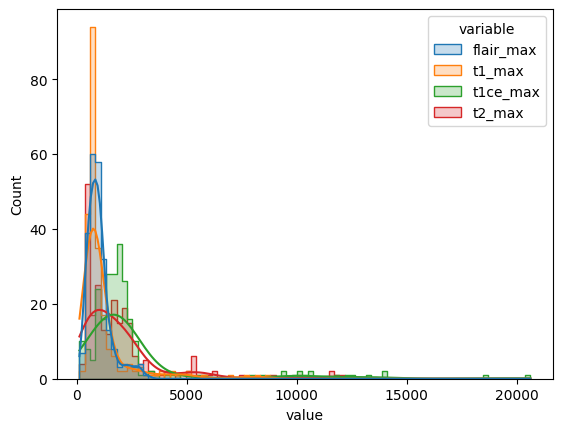

In [ ]:
melt_df = meta_df.melt(id_vars='flair_mima', value_vars=['flair_max','t1_max','t1ce_max','t2_max'])
sns.histplot(data=melt_df, x='value',hue='variable', kde=True, element="step")

<Axes: xlabel='value', ylabel='Density'>

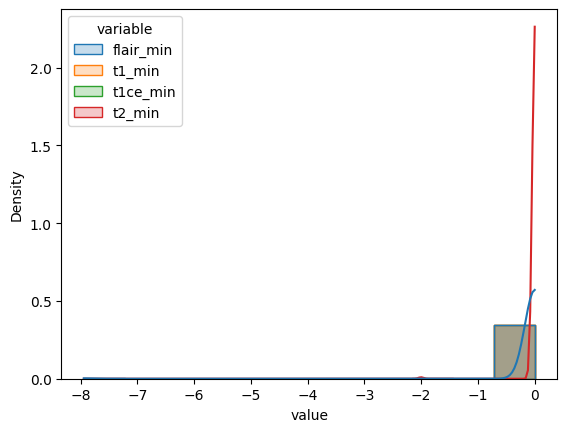

In [ ]:
melt_df = meta_df.melt(id_vars='flair_mima', value_vars=['flair_min','t1_min','t1ce_min','t2_min'])
sns.histplot(data=melt_df, x='value',hue='variable', kde=True, element="step", stat="density")